In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Configure visualization settings
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [13]:
"""
SECTION 1: DATASET LOADING AND INITIAL EXPLORATION
"""

# Load the dataset
df = pd.read_csv('data.csv')

# Display shape
print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")

# Display first records
print(f"First 10 Records:")
print(df.head(10))

# Display column names and data types
print(f"Data Types:")
print(df.dtypes)

# Display basic information
print(f"Dataset Info:")
df.info()

Dataset Dimensions: 692703 rows x 79 columns
First 10 Records:
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   
5                389             433                  11   
6                 88            1088                   9   
7                 80          579225                 132   
8              49666               3                   2   
9              49413               4                   3   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12              

In [14]:
"""
SECTION 2: DATA QUALITY ASSESSMENT
"""

# Handle infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
})

print(f"Missing Values Analysis:")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# Check for duplicates
duplicates_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates_count}")

# Data type summary
print(f"Data Type Distribution:")
print(df.dtypes.value_counts())

Missing Values Analysis:
Total Missing Values: 2594
Duplicate Rows: 81909
Data Type Distribution:
int64      54
float64    24
str         1
Name: count, dtype: int64


In [15]:
"""
SECTION 3: DATA CLEANING AND IMPUTATION
"""

# Strip whitespace from column names to avoid detection issues
df.columns = df.columns.str.strip()

# Identify numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Identify and preserve the target column before feature selection
# Case-insensitive detection: look for 'label' in any case
label_col = next((c for c in df.columns if c.lower() == 'label'), None)
label_values = df[label_col].copy() if label_col is not None else None

if label_col is not None:
    print(f"Label column preserved as target: {label_col}")
    print(f"Target variable classes: {label_values.unique()}")
else:
    print("No Label column detected in the dataset")

# Store original missingness before imputation
missing_pct_before = df.isnull().mean()

# Handle missing values in numeric columns using median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        print(f"Imputing missing values in '{col}' with median")
        df[col] = df[col].fillna(df[col].median())

# Handle missing values in categorical columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        print(f"Imputing missing values in '{col}' with mode")
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates(keep='first')

print(f"Remaining Duplicates: {df.duplicated().sum()}")
print(f"Cleaned Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total Missing Values After Cleaning: {df.isnull().sum().sum()}")

Label column preserved as target: Label
Target variable classes: <ArrowStringArray>
[          'BENIGN',    'DoS slowloris', 'DoS Slowhttptest',
         'DoS Hulk',    'DoS GoldenEye',       'Heartbleed']
Length: 6, dtype: str
Imputing missing values in 'Flow Bytes/s' with median
Imputing missing values in 'Flow Packets/s' with median


/tmp/ipykernel_84032/1588108558.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Remaining Duplicates: 0
Cleaned Dataset Shape: 610794 rows x 79 columns
Total Missing Values After Cleaning: 0


In [16]:
"""
SECTION 4: DESCRIPTIVE STATISTICAL ANALYSIS
"""

# Comprehensive statistical summary
stats_summary = df[numeric_cols].describe().T
stats_summary = stats_summary.rename(columns={
    '25%': 'Q1',
    '50%': 'Median',
    '75%': 'Q3',
    'std': 'Std Dev',
    'min': 'Min',
    'max': 'Max'
})

# Calculate additional statistics
stats_summary['Range'] = stats_summary['Max'] - stats_summary['Min']
stats_summary['IQR'] = stats_summary['Q3'] - stats_summary['Q1']
stats_summary['Skewness'] = df[numeric_cols].skew()
stats_summary['Kurtosis'] = df[numeric_cols].kurtosis()
stats_summary = stats_summary[['count', 'mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Range', 'IQR', 'Skewness', 'Kurtosis']]
stats_summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Range', 'IQR', 'Skewness', 'Kurtosis']
stats_summary = stats_summary.round(4)

print("\nComprehensive Statistics:")
print(stats_summary)

# Identify target variable and analyze class distribution
if label_col is not None:
    label_stats = (
        label_values
        .value_counts(dropna=False)
        .rename_axis('Label')
        .reset_index(name='Count')
    )

    # Calculate class imbalance ratio
    imbalance_ratio = label_stats['Count'].max() / label_stats['Count'].min()
    print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

    # Provide interpretation of imbalance ratio and potential implications for modeling ( > 3 indicates significant imbalance)
    if imbalance_ratio > 3:
        print("WARNING: Significant class imbalance detected!")
    else:
        print("Class distribution is relatively balanced")



Comprehensive Statistics:
                                Count          Mean       Std Dev         Min  \
Destination Port             610794.0  6.432112e+03  1.660331e+04         0.0   
Flow Duration                610794.0  3.175187e+07  4.421601e+07        -1.0   
Total Fwd Packets            610794.0  1.055500e+01  7.957174e+02         1.0   
Total Backward Packets       610794.0  1.154310e+01  1.048114e+03         0.0   
Total Length of Fwd Packets  610794.0  6.258788e+02  6.560426e+03         0.0   
Total Length of Bwd Packets  610794.0  1.927276e+04  2.386714e+06         0.0   
Fwd Packet Length Max        610794.0  2.631687e+02  6.361170e+02         0.0   
Fwd Packet Length Min        610794.0  1.539820e+01  4.000640e+01         0.0   
Fwd Packet Length Mean       610794.0  6.698220e+01  1.627244e+02         0.0   
Fwd Packet Length Std        610794.0  9.393380e+01  2.386586e+02         0.0   
Bwd Packet Length Max        610794.0  1.882823e+03  2.708249e+03         0.0   
B

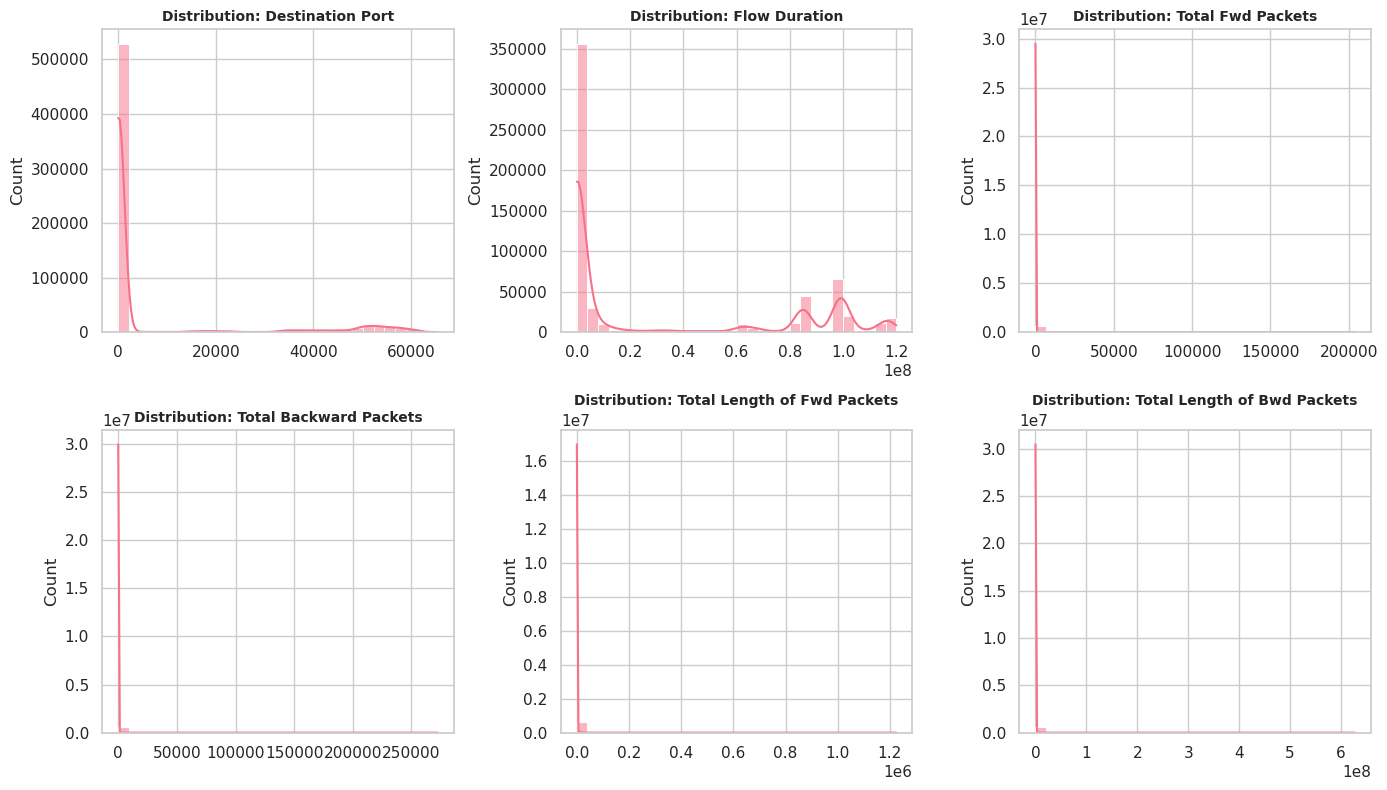


 Box Plot Analysis for Outlier Detection:


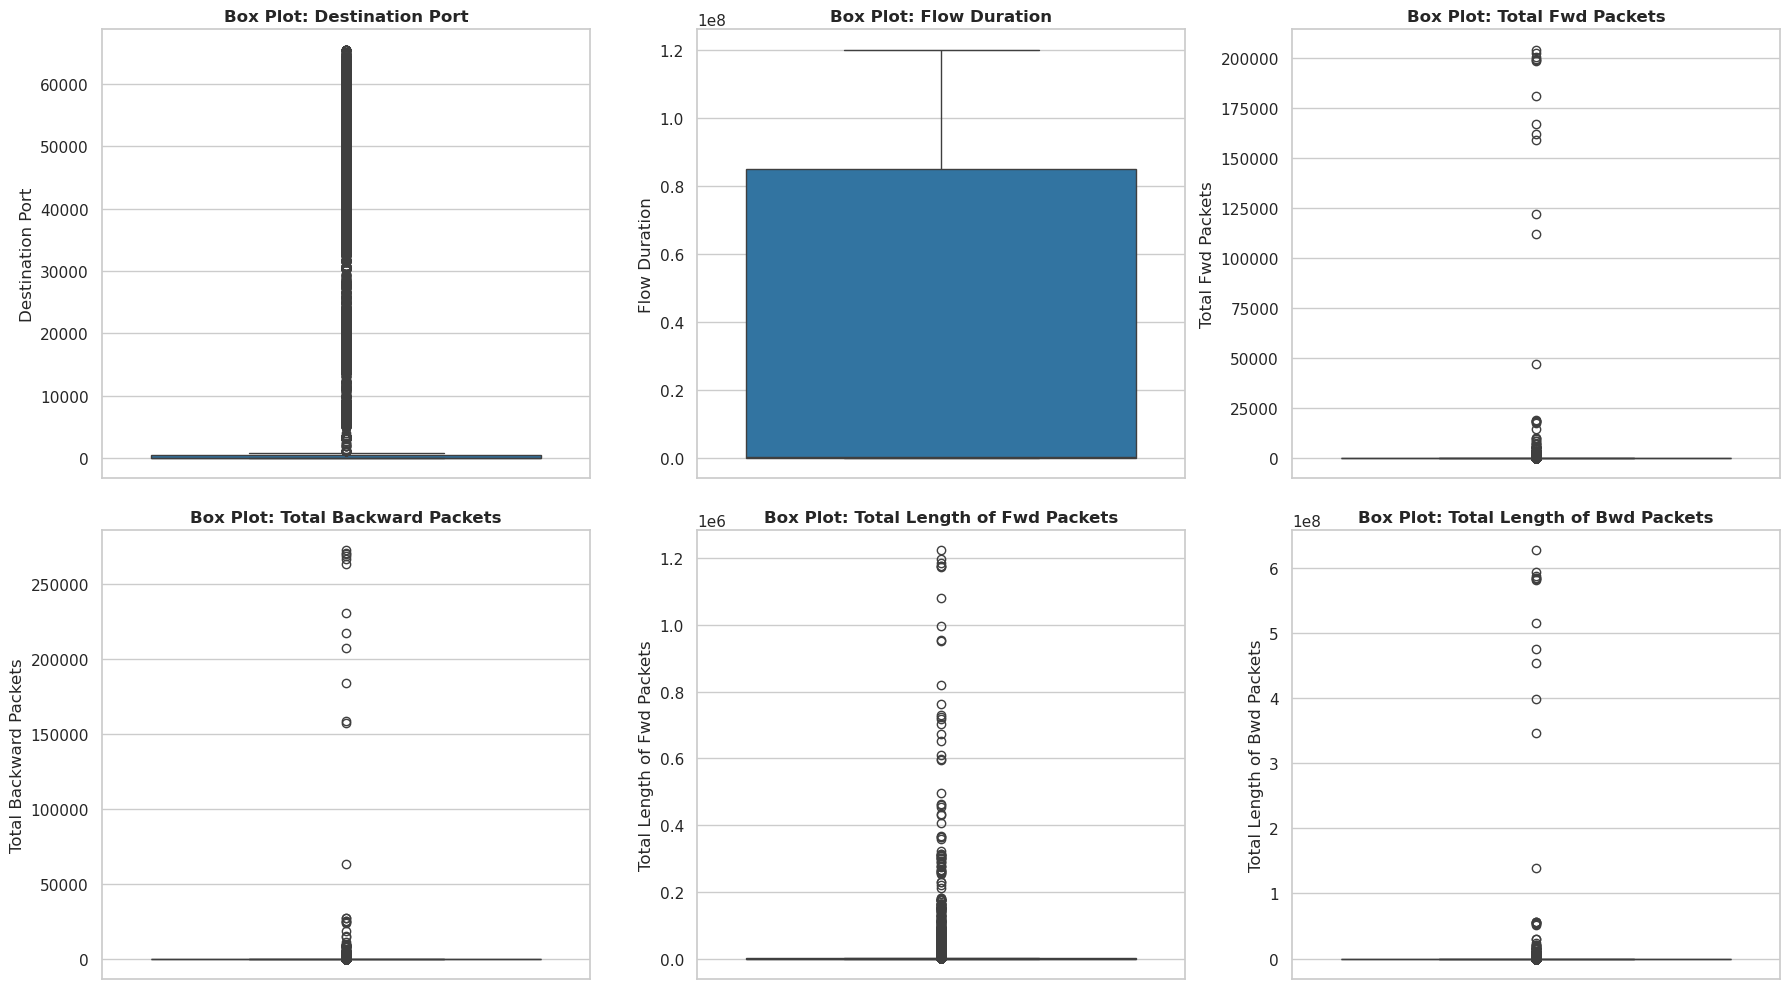


 Categorical Features Distribution:


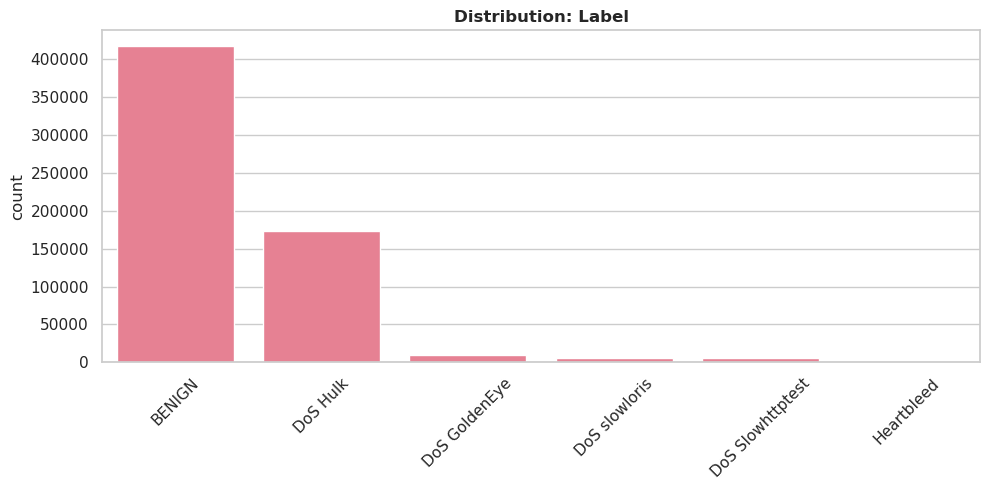

In [17]:
"""
SECTION 5: DATA DISTRIBUTION VISUALIZATION
"""

# Distribution plots for numeric columns
# Subplot 1: Histograms with KDE
n_cols = min(6, len(numeric_cols))
cols_sample = numeric_cols[:n_cols]

fig, axes_hist = plt.subplots(2, 3, figsize=(14, 8))
axes_hist = axes_hist.ravel()

for i, col in enumerate(cols_sample):
    axes_hist[i].set_title(f'Distribution: {col}', fontweight='bold', fontsize=10)
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=axes_hist[i])
    axes_hist[i].set_xlabel('')

for j in range(len(cols_sample), len(axes_hist)):
    fig.delaxes(axes_hist[j])

plt.tight_layout()
plt.show()

# Box plots for outlier detection
print("\n Box Plot Analysis for Outlier Detection:")
plot_cols = cols_sample[:6]
fig, axes_box = plt.subplots(2, 3, figsize=(18, 10))
axes_box = axes_box.ravel()

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes_box[i], color='tab:blue')
    axes_box[i].set_title(f'Box Plot: {col}', fontweight='bold')

for j in range(len(plot_cols), len(axes_box)):
    fig.delaxes(axes_box[j])

plt.tight_layout()
plt.show()

# Categorical distributions
if categorical_cols:
    print(f"\n Categorical Features Distribution:")
    for col in categorical_cols:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution: {col}', fontweight='bold', fontsize=12)
        plt.xlabel('')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Showing heatmap for top 20 most correlated numeric features

Top Positive Correlations (excluding diagonal):
                  Feature 1            Feature 2  Correlation
          Fwd Header Length  Fwd Header Length.1     1.000000
Total Length of Fwd Packets    Subflow Fwd Bytes     1.000000
          Total Fwd Packets  Subflow Fwd Packets     1.000000
     Total Backward Packets  Subflow Bwd Packets     1.000000
     Fwd Packet Length Mean Avg Fwd Segment Size     1.000000
              Fwd PSH Flags       SYN Flag Count     1.000000
     Bwd Packet Length Mean Avg Bwd Segment Size     1.000000
Total Length of Bwd Packets    Subflow Bwd Bytes     1.000000
     Total Backward Packets    Bwd Header Length     0.999933
          Bwd Header Length  Subflow Bwd Packets     0.999933


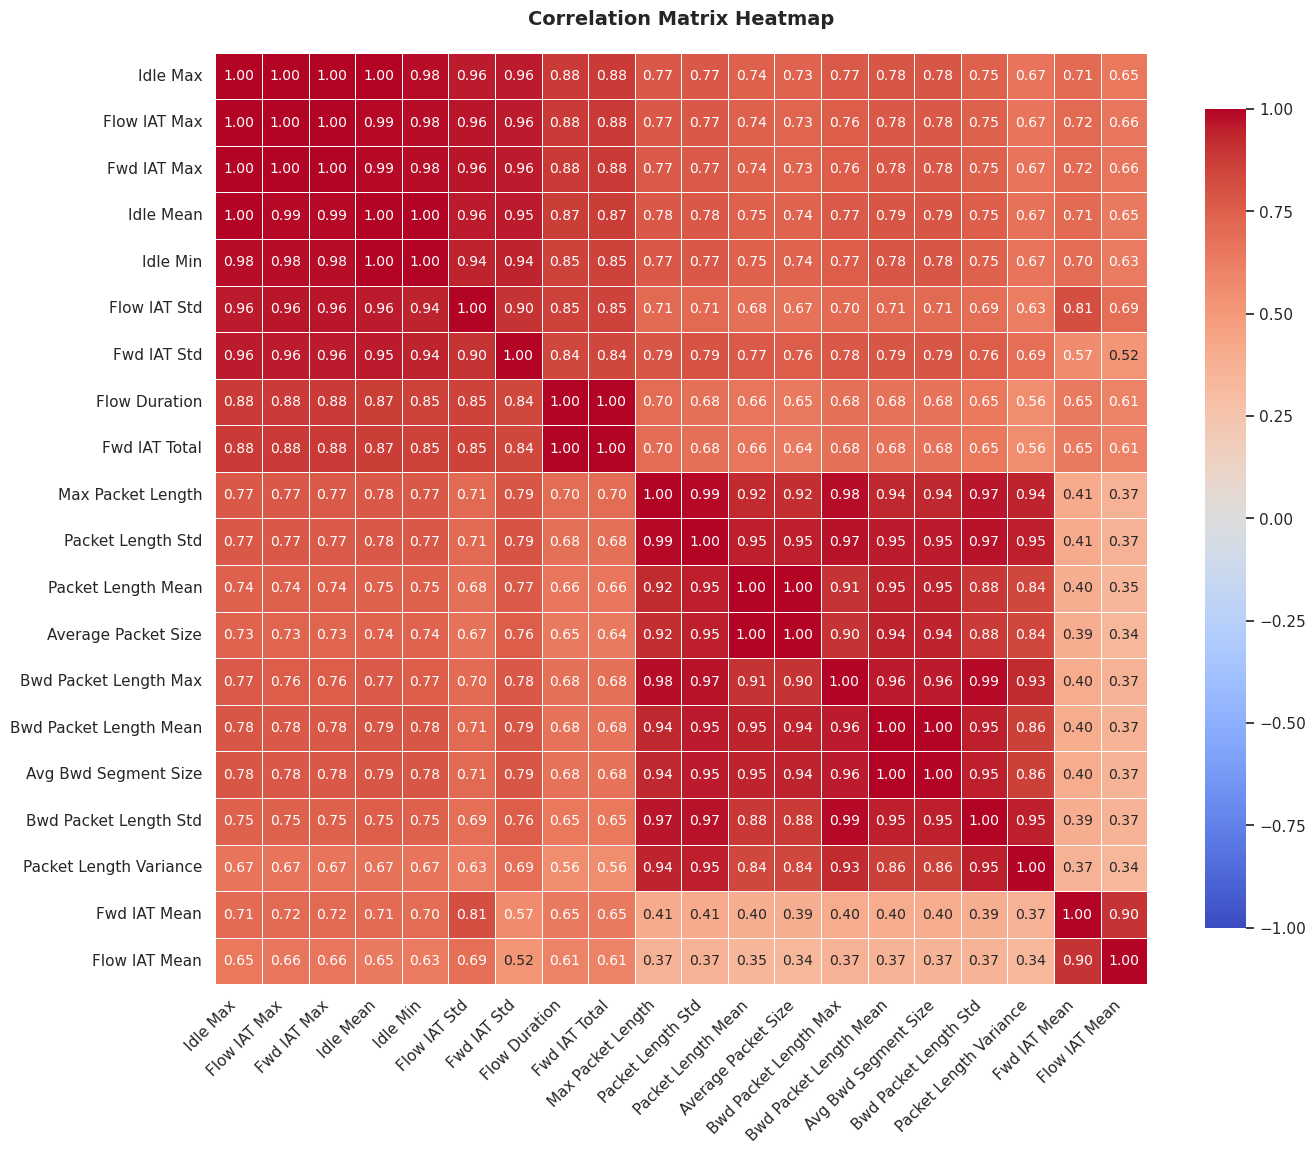


 Highly Correlated Features (|r| > 0.8):
                  Feature 1                   Feature 2  Correlation
          Fwd Header Length         Fwd Header Length.1     1.000000
Total Length of Fwd Packets           Subflow Fwd Bytes     1.000000
          Total Fwd Packets         Subflow Fwd Packets     1.000000
     Total Backward Packets         Subflow Bwd Packets     1.000000
     Fwd Packet Length Mean        Avg Fwd Segment Size     1.000000
              Fwd PSH Flags              SYN Flag Count     1.000000
     Bwd Packet Length Mean        Avg Bwd Segment Size     1.000000
Total Length of Bwd Packets           Subflow Bwd Bytes     1.000000
     Total Backward Packets           Bwd Header Length     0.999933
          Bwd Header Length         Subflow Bwd Packets     0.999933
        Fwd Header Length.1         Subflow Fwd Packets     0.999768
          Total Fwd Packets         Fwd Header Length.1     0.999768
          Total Fwd Packets           Fwd Header Length     0

In [18]:
"""
SECTION 6: CORRELATION ANALYSIS
"""

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Select a smaller set of features for a cleaner heatmap when there are many numeric columns
if len(corr_matrix.columns) > 20:
    top_cols = corr_matrix.abs().sum().sort_values(ascending=False).head(20).index
    plot_corr = corr_matrix.loc[top_cols, top_cols]
    print(f"Showing heatmap for top {len(top_cols)} most correlated numeric features")
else:
    plot_corr = corr_matrix

print("\nTop Positive Correlations (excluding diagonal):")

# Extract upper triangle of the correlation matrix without diagonal
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Feature 1': corr_matrix.columns[i],
            'Feature 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False, key=abs)
print(corr_df.head(10).to_string(index=False))

# Visualize correlation heatmap
plt.figure(figsize=(14, 12))


# Plot heatmap with mask to show only lower triangle
sns.heatmap(plot_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (potential multicollinearity)
print("\n Highly Correlated Features (|r| > 0.8):")
high_corr_pairs = corr_df[corr_df['Correlation'].abs() > 0.8]

# Display highly correlated pairs
if len(high_corr_pairs) > 0:
    print(high_corr_pairs[['Feature 1', 'Feature 2', 'Correlation']].to_string(index=False))
else:
    print("No highly correlated pairs found.")


Columns with Outliers:
                    Feature  Outlier_Count  Lower_Bound Upper_Bound
              Fwd Packets/s         139977     -2739.46     4566.05
             Flow Packets/s         137714     -3994.23     6657.53
                Fwd IAT Min         137230       -71.00      121.00
               Flow Bytes/s         136537    -25293.05    42476.80
              Bwd IAT Total         135621   -517950.38   863250.62
                Bwd IAT Max         135358   -322644.00   537740.00
             PSH Flag Count         134161         0.00        0.00
               Bwd IAT Mean         133953    -88947.41   148245.69
                 Active Max         130255     -1524.00     2540.00
                Active Mean         130252     -1524.00     2540.00
                 Active Min         127494     -1515.00     2525.00
                Bwd IAT Std         125469   -100224.42   167040.69
              Bwd Packets/s         119136       -96.19      160.50
               Flow IAT 

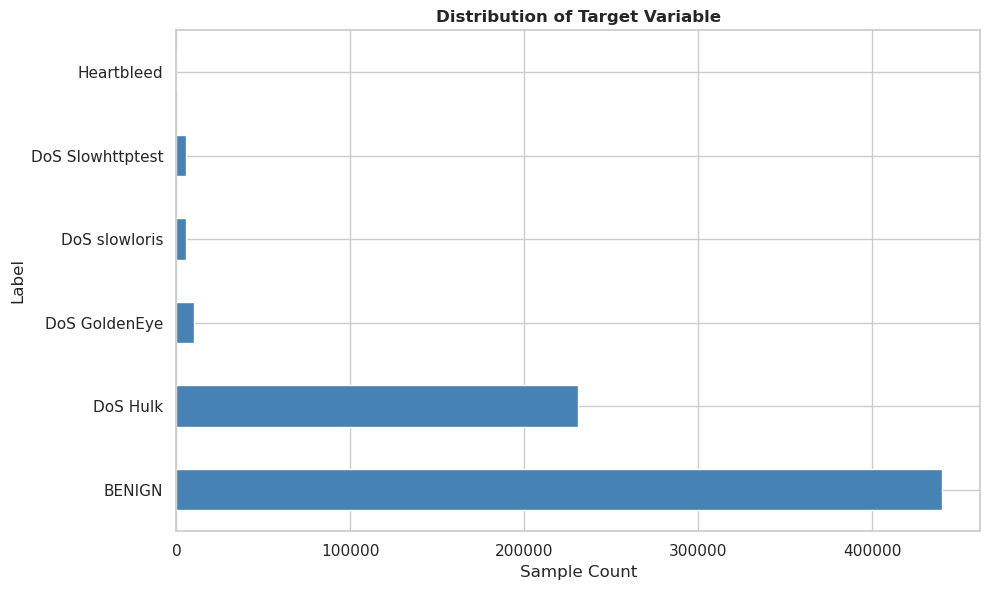

In [19]:
"""
SECTION 7: OUTLIER DETECTION AND ANALYSIS
"""

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': len(outliers),
            'Lower_Bound': f"{lower_bound:.2f}",
            'Upper_Bound': f"{upper_bound:.2f}"
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
    print("\nColumns with Outliers:")
    print(outlier_df.to_string(index=False))
else:
    print("\nNo outliers detected using IQR method.")
    
# Distribution of sample sizes across classes
if label_col is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    label_values.value_counts().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Sample Count')
    ax.set_title('Distribution of Target Variable', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [38]:
"""
SECTION 8: FEATURE SELECTION AND DIMENSIONALITY REDUCTION
"""

features_to_remove = []
removal_reasons = []

# Criterion 1: Low Variance Features (variance < 0.01)
print("\n 1. LOW VARIANCE FEATURES (potential constant values):")
low_variance_cols = []
variance_threshold = 1
for col in numeric_cols:
    if col == label_col:
        continue
    variance = df[col].var()
    if variance < variance_threshold:
        low_variance_cols.append(col)
        print(f"WARNING: {col}: Variance = {variance:.6f}")
        features_to_remove.append(col)
        removal_reasons.append(f"Low variance ({variance:.6f})")

if not low_variance_cols:
    print("No low variance features detected")

# Criterion 2: Highly Correlated Features (|r| > 0.80)
print("\n 2. REDUNDANT FEATURES (high multicollinearity |r| > 0.80):")
redundant_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        if col_i == label_col or col_j == label_col:
            continue
        if abs(corr_matrix.iloc[i, j]) > 0.80:
            redundant_features.add(col_j)
            print(f"WARNING: {col_j} highly correlated with {col_i} (r={corr_matrix.iloc[i, j]:.4f})")
            if col_j not in features_to_remove:
                features_to_remove.append(col_j)
                removal_reasons.append(f"High multicollinearity ({corr_matrix.iloc[i, j]:.4f})")

if not redundant_features:
    print("No highly correlated features detected")

# Criterion 3: High original missingness before imputation
print("\n 3. EXCESSIVE ORIGINAL MISSING VALUES (>20% before imputation):")
high_missing_cols = []
for col in df.columns:
    if col == label_col:
        continue
    missing_pct = missing_pct_before.get(col, 0) * 100
    if missing_pct > 20:
        high_missing_cols.append(col)
        print(f"WARNING: {col}: {missing_pct:.2f}% missing before imputation")
        if col not in features_to_remove:
            features_to_remove.append(col)
            removal_reasons.append(f"High original missingness ({missing_pct:.2f}%)")

if not high_missing_cols:
    print("No features with excessive original missing values detected")

# Criterion 4: Low Target Relevance (|correlation| < 0.20 with target variable)
if label_col is not None:
    print(f"\n 4. LOW TARGET RELEVANCE: checking numerical features against target '{label_col}'")
    try:
        # Encode target variable for correlation calculation using current df (after cleaning)
        label_encoded = pd.factorize(df[label_col])[0]
        low_relevance_cols = []
        relevance_threshold = 0.20
        
        for col in numeric_cols:
            if col == label_col or df[col].nunique() <= 1:
                continue
            # Calculate Pearson correlation with target using encoded labels
            corr_with_target = df[col].corr(pd.Series(label_encoded, index=df.index))
            if pd.notna(corr_with_target) and abs(corr_with_target) < relevance_threshold:
                low_relevance_cols.append(col)
                print(f"WARNING: {col}: very low correlation with target (r={corr_with_target:.4f})")
                if col not in features_to_remove:
                    features_to_remove.append(col)
                    removal_reasons.append(f"Very low target relevance (r={corr_with_target:.4f})")
        
        if not low_relevance_cols:
            print(f"No features with very low target relevance detected (threshold: |r| < {relevance_threshold})")
    except Exception as e:
        print(f"Error during target relevance check: {e}")
        print("Skipping Criterion 4")
else:
    print("\n 4. LOW TARGET RELEVANCE: skipped - no target column found")
    print(f"   Available columns: {list(df.columns)}")

# Remove the target column from removal list so it is always preserved
if label_col is not None and label_col in features_to_remove:
    features_to_remove.remove(label_col)

# Feature removal based on the above criteria
features_to_remove = sorted(set(features_to_remove))
original_shape = df.shape

df_cleaned = df.drop(columns=features_to_remove, errors='ignore')

print(f"\n FINAL RESULTS:")
print(f"Features removed: {len(features_to_remove)}")
print(f"Original Dataset Shape: {original_shape[0]} rows X {original_shape[1]} columns")
print(f"Cleaned Dataset Shape: {df_cleaned.shape[0]} rows X {df_cleaned.shape[1]} columns")
if features_to_remove:
    print(f"Removed features: {features_to_remove[:10]}{'...' if len(features_to_remove) > 10 else ''}")



 1. LOW VARIANCE FEATURES (potential constant values):

 2. REDUNDANT FEATURES (high multicollinearity |r| > 0.80):

 3. EXCESSIVE ORIGINAL MISSING VALUES (>20% before imputation):
No features with excessive original missing values detected

 4. LOW TARGET RELEVANCE: checking numerical features against target 'Label'

 FINAL RESULTS:
Features removed: 70
Original Dataset Shape: 610794 rows X 79 columns
Cleaned Dataset Shape: 610794 rows X 9 columns
Removed features: ['ACK Flag Count', 'Active Max', 'Active Mean', 'Active Min', 'Active Std', 'Average Packet Size', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk']...


In [39]:
"""
SAVE CLEANED DATAFRAME FOR CLASSIFICATION NOTEBOOK
"""

# Save df_cleaned for Classification notebook
with open('df_cleaned.pkl', 'wb') as f:
    pickle.dump(df_cleaned, f)

print("Cleaned dataframe saved to 'df_cleaned.pkl' for Classification notebook")

Cleaned dataframe saved to 'df_cleaned.pkl' for Classification notebook
